File XLZD_200ty(NR).txt not found in the directory.
File neutrino_fog.txt not found in the directory.
File XENONnT_2023_24.txt not found in the directory.
File PandaX_2024.txt not found in the directory.
File AllLimits-2024.txt not found in the directory.
File DarkSide_2023.txt not found in the directory.
File LZ_SR1_Migdal_2023.txt not found in the directory.
File XENON1T_Migdal_2020(S2-only)_1ty.txt not found in the directory.


/tmp/ipykernel_40871/1806070395.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=15)


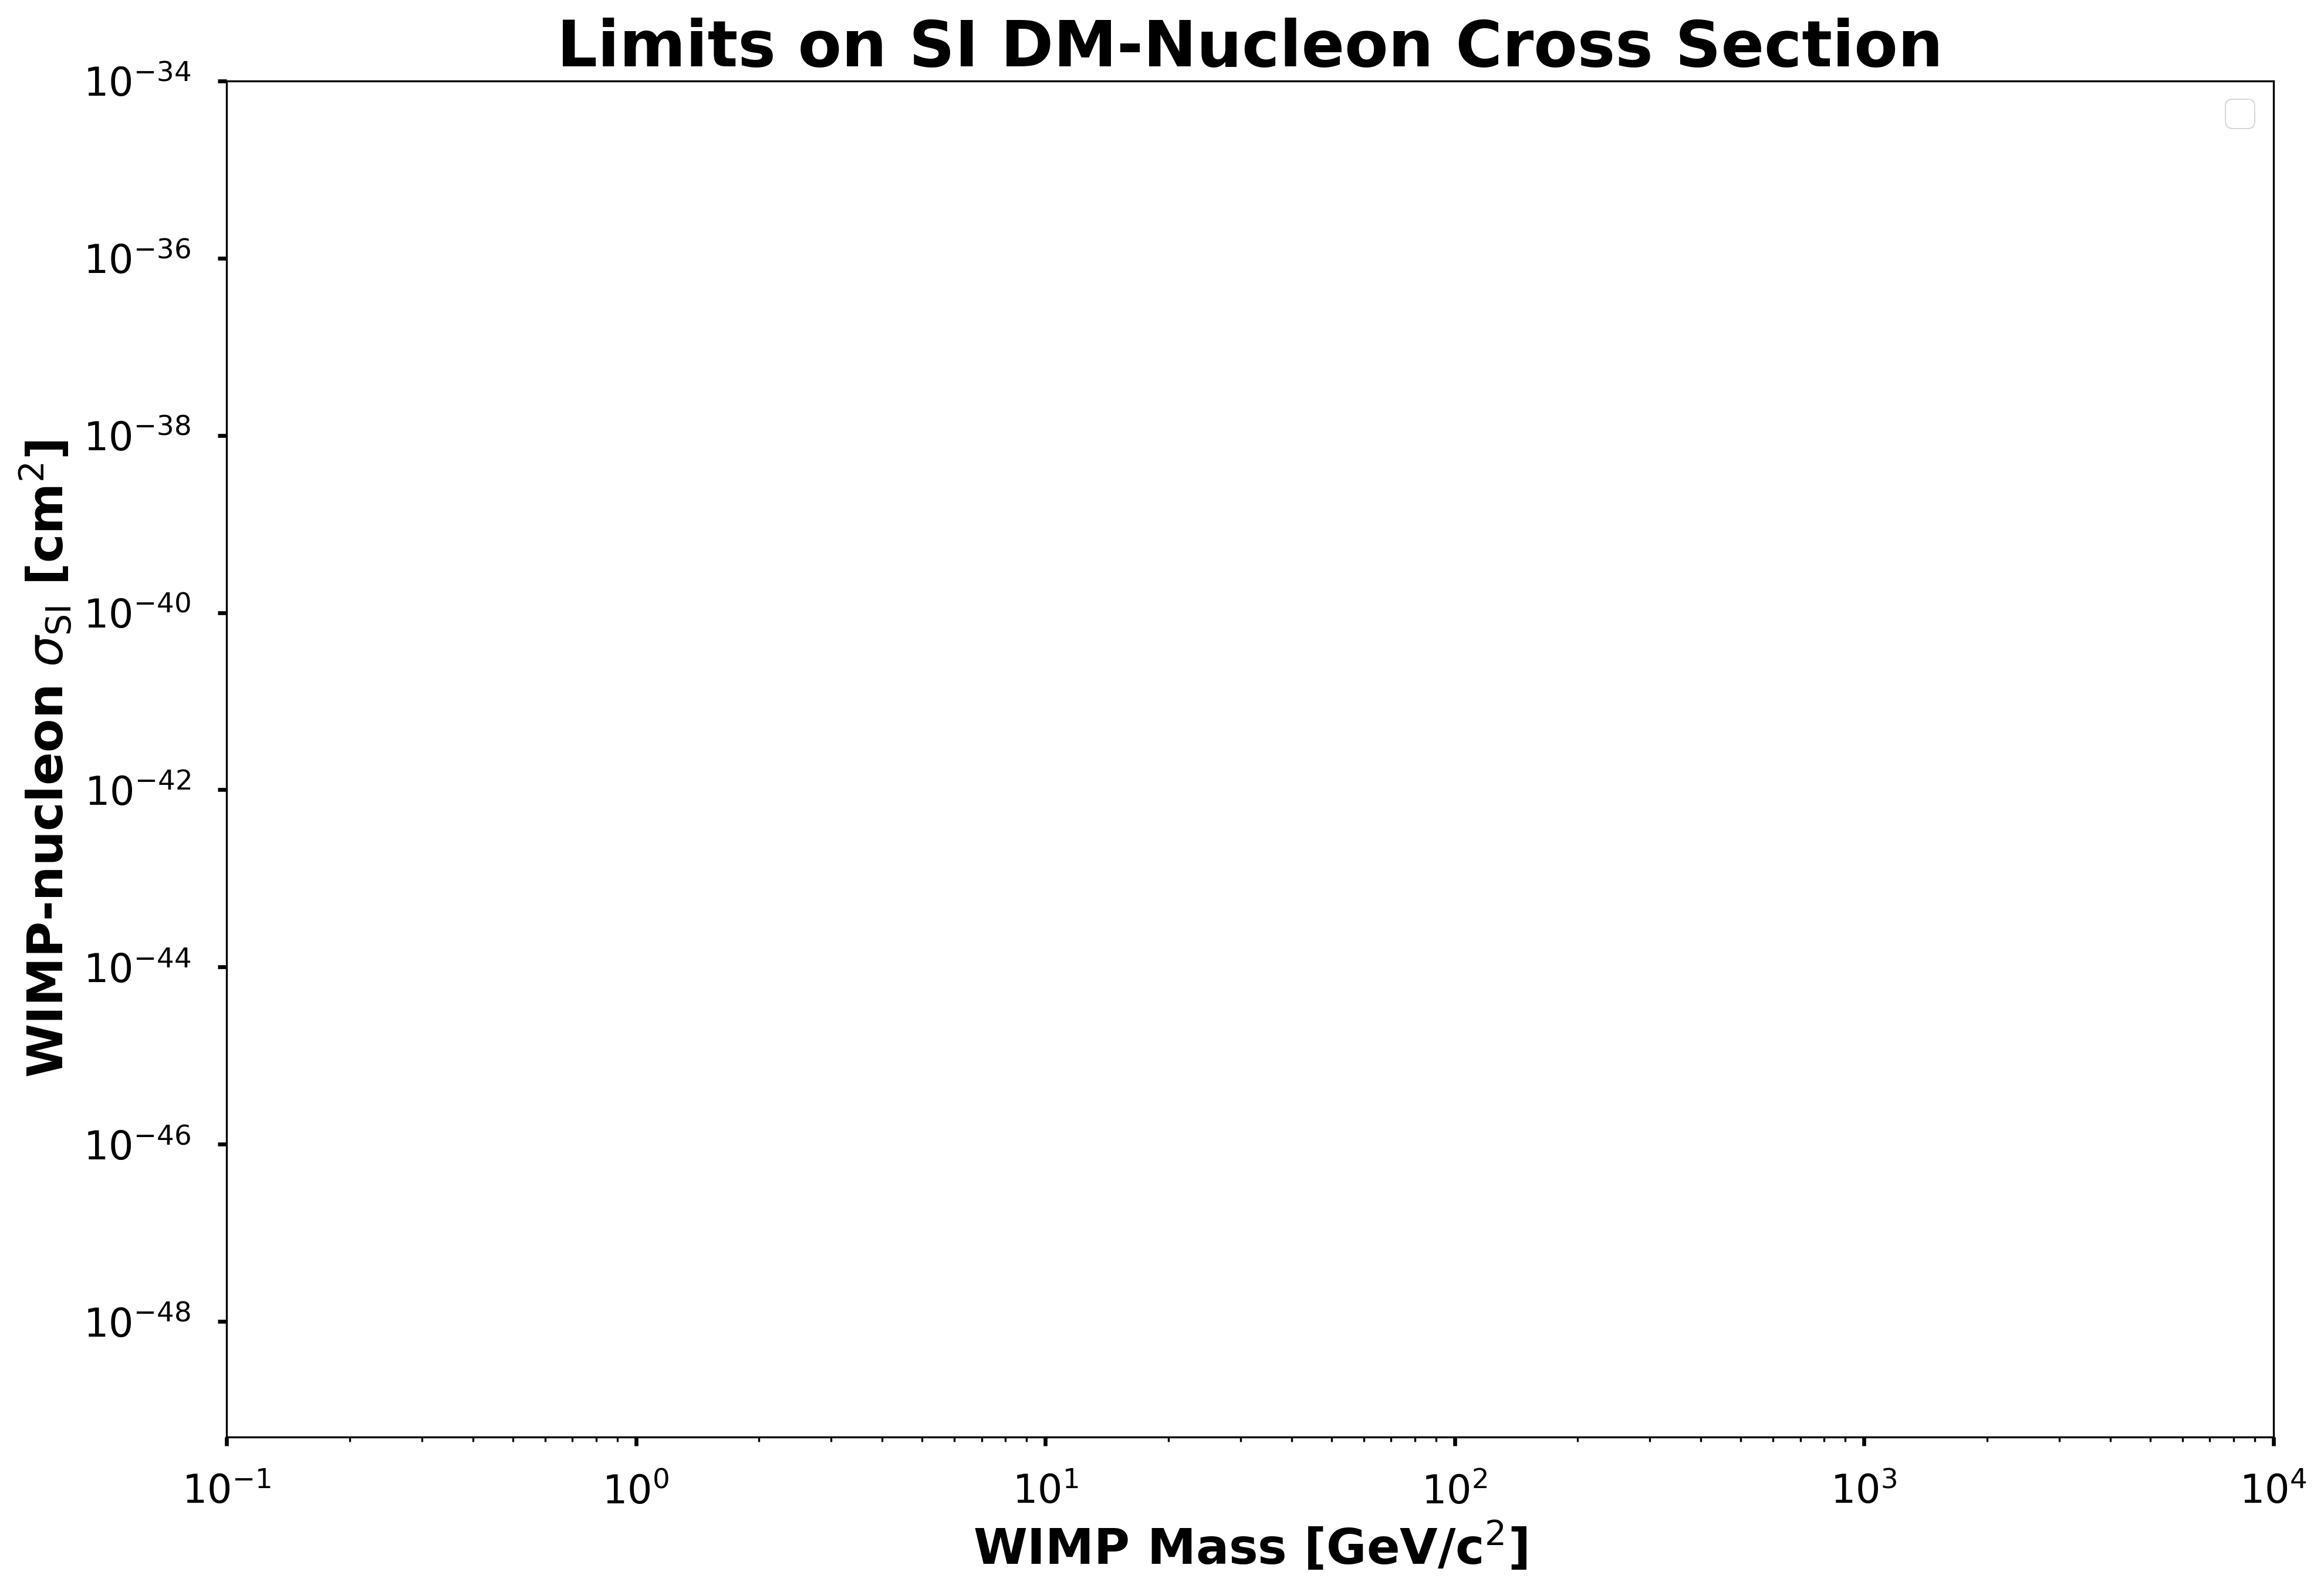

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_data_from_files(master_path, filenames):
    plt.style.use('seaborn-v0_8-poster')
    a, ax = plt.subplots(figsize=(15, 10), dpi=300)

    projection_label = 'Projections'
    label_added_projection = False

    for filename in filenames:
        file_path = os.path.join(master_path, filename)

        if os.path.exists(file_path):
            data = np.loadtxt(file_path)
            x = data[:, 0]
            y = data[:, 1]

            if filename not in ['neutrino_fog.txt', 'XLZD_200ty(NR).txt', 'AllLimits-2024.txt']:
                line, = ax.plot(x, y, label=filename.replace('.txt', ''), lw=2)

            elif filename == 'XLZD_200ty(NR).txt':
                line, = ax.plot(x, y, label=filename.replace('.txt', ''), lw=2, linestyle='--')
                if not label_added_projection:
                    ax.plot([], [], label=projection_label, linestyle='--', color=line.get_color())
                    label_added_projection = True

            elif filename == 'neutrino_fog.txt':
                ax.plot(x, y, color='blue', lw=2)
                ax.fill_between(x, y, color='lightblue', alpha=0.5)
                ax.text(0.2, 5e-45, "Neutrino Fog", color='black', fontsize=12, ha='left', va='bottom', fontweight='bold')

            elif filename == 'AllLimits-2024.txt':
                line, = ax.plot(x, y, color="black", label=filename.replace('.txt', ''), lw=2)
                ax.fill_between(x, y, 1e-34, color='lime', alpha=0.3)
                ax.text(1, 1e-36, 'Excluded Region', color='black', fontsize=12, ha='left', va='bottom', fontweight='bold')

            if filename != 'neutrino_fog.txt':
                ax.text(x[int(len(x) * 0.7)], y[int(len(x) * 0.7)] * 3.4, filename.replace('.txt', ''),
                        color=line.get_color(), fontsize=12, ha='left', va='bottom', fontweight='bold')

        else:
            print(f"File {filename} not found in the directory.")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim([0.1, 1e4])
    ax.set_ylim([5e-50, 1e-34])
    ax.set_xlabel(r'WIMP Mass [GeV/c$^2$]', fontsize=20, fontweight='bold')
    ax.set_ylabel(r'WIMP-nucleon $\sigma_{\rm SI}$ [cm$^2$]', fontsize=20, fontweight='bold')
    ax.set_title("Limits on SI DM-Nucleon Cross Section", fontsize=26, fontweight='bold')
    ax.legend(loc='upper right', fontsize=15)

    plt.show()

master_path = '/home/goldy/Documents/Stage_M1/FlameFitSimple/analyses/Plotting'
filenames = [
    'XLZD_200ty(NR).txt', 'neutrino_fog.txt',
    'XENONnT_2023_24.txt', "PandaX_2024.txt", "AllLimits-2024.txt",
    "DarkSide_2023.txt", "LZ_SR1_Migdal_2023.txt",
    "XENON1T_Migdal_2020(S2-only)_1ty.txt"
]

plot_data_from_files(master_path, filenames)


The data for plotting these curves is hosted on : https://github.com/cajohare/DirectDetectionPlots/tree/main/data/limits/Nucleon/SI

Neutrino Fog : 

Neutrinos interactions, such as Coherent Elastic neutrino Nucleus Scattering (CEvNS) or neutrinos elastic scattering, are of particular interest to the under- standing of this elusive particle properties but can also be used as a probe to study unreachable systems such as the core of nuclear power plant or the Sun,

In addition to the neutrino-electron scattering, neutrinos can also scatter off the nu- cleus through the exchange of a Z0 boson (NC). In the case of a low-energy neutrino (< O(100) MeV) the neutrino will interact coherently10 with the whole nucleus, while at higher energy, it will interact with the individual nucleons (or quarks). In 1974, Daniel Z. Freedman predicted the existence of an elastic scattering process that would benefit from a coherent enhancement proportional to the size of the nucleus, called coherent elastic neutrino-nucleus scattering [95].

Here, the floor is defined as the SI WIMP-nucleon cross-section for which an experiment has a 90% probability to detect a WIMP with a scattering cross-section of at least that size at ≥ 3σ.

 is important to mention that CEvNS doesn't represent a strict limit which makes,the WIMP direct detection search impossible (the notion of neutrino floor used in the
past). It is rather a background source whose signature depends on the neutrino source
energy and only impacts some specific part of the (σSI, m ) parameter space, displayed nχ
in figure 2.19 for xenon target, while the rest remains accessible through larger exposure, It is important to emphasise that the neutrino floor does not pose a hard limit for future experiments such as XLZD. This is explored in greater detail in reference [230], which discusses the alternative formulation of a so-called ‘neutrino fog.’ The basic idea is that with sufficient exposure, the floor can be pushed past due to small differences in spectral shape between WIMPs and neutrinos. Furthermore, the neu- trino floor, defined robustly in reference [230] as the boundary of the neutrino fog
 234 of 265
6.3. WIMPs in different design scenarios 6. Design considerations for XLZD
 via a calculation free from assumptions about exposure and threshold, depends on the neutrino flux uncertainties. A reduction in these as a result of future measure- ment results from dedicated neutrino experiments will thus push down the neutrino floor and extend the WIMP parameter space that XLZD can probe.


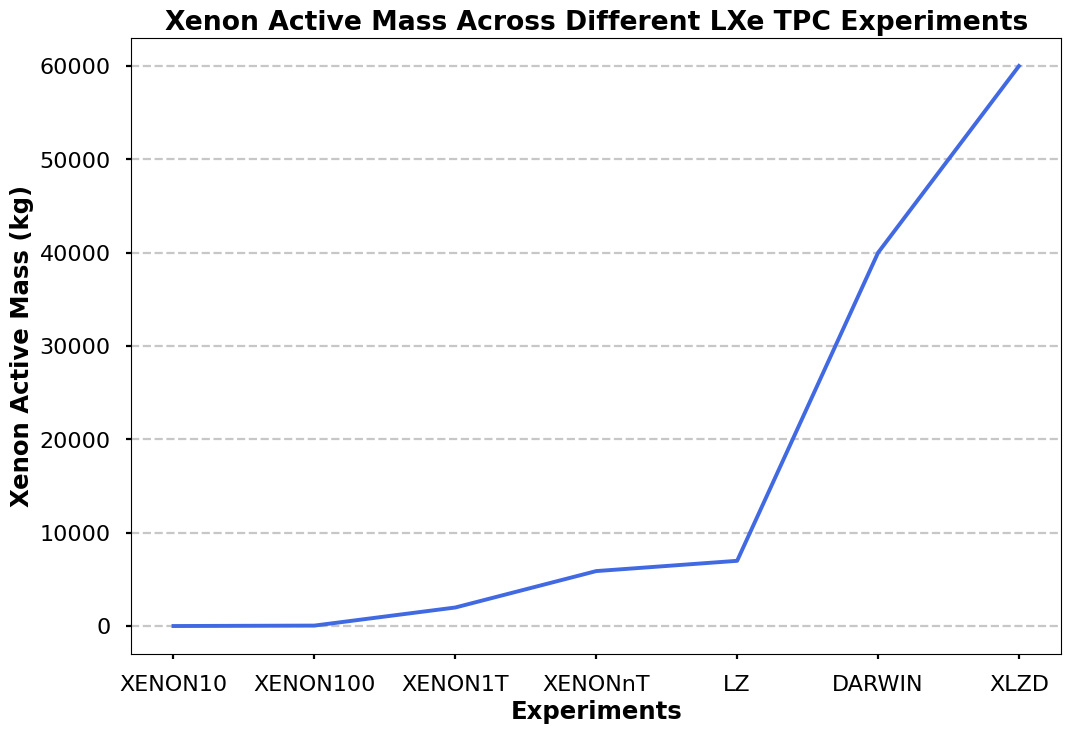

In [2]:
import matplotlib.pyplot as plt

# Experiment names
experiments = ["XENON10", "XENON100", "XENON1T", "XENONnT", "LZ","DARWIN", "XLZD"]

# Corresponding Xenon mass (in kg)
xenon_mass = [15, 62, 2000, 5900, 7000,40000,60000]
# Create plot
plt.figure(figsize=(12,8))
plt.plot(experiments, xenon_mass, color='royalblue')
plt.xlabel("Experiments",fontweight="bold")
plt.ylabel("Xenon Active Mass (kg)",fontweight="bold")
plt.title("Xenon Active Mass Across Different LXe TPC Experiments", fontweight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.style.use('seaborn-v0_8-poster')
plt.show()


# Same plot as above but with Migdal results from XLZD 

Missing files: XLZD_200ty(NR).txt, neutrino_fog.txt, AllLimits-2024.txt, XENON1T_Migdal_2020(S2-only)_1ty.txt, XLZD_60t_750ty_migdal(This study).txt, XLZD_40t_140ty_migdal(This study).txt, XLZD_80t_950ty_migdal(This study).txt, XENON1T_Migdal_2020(S1-S2)_1ty.txt, LZ_SR1_Migdal_2023 _low_0.9ty.txt


/tmp/ipykernel_40871/758839152.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', fontsize=10)


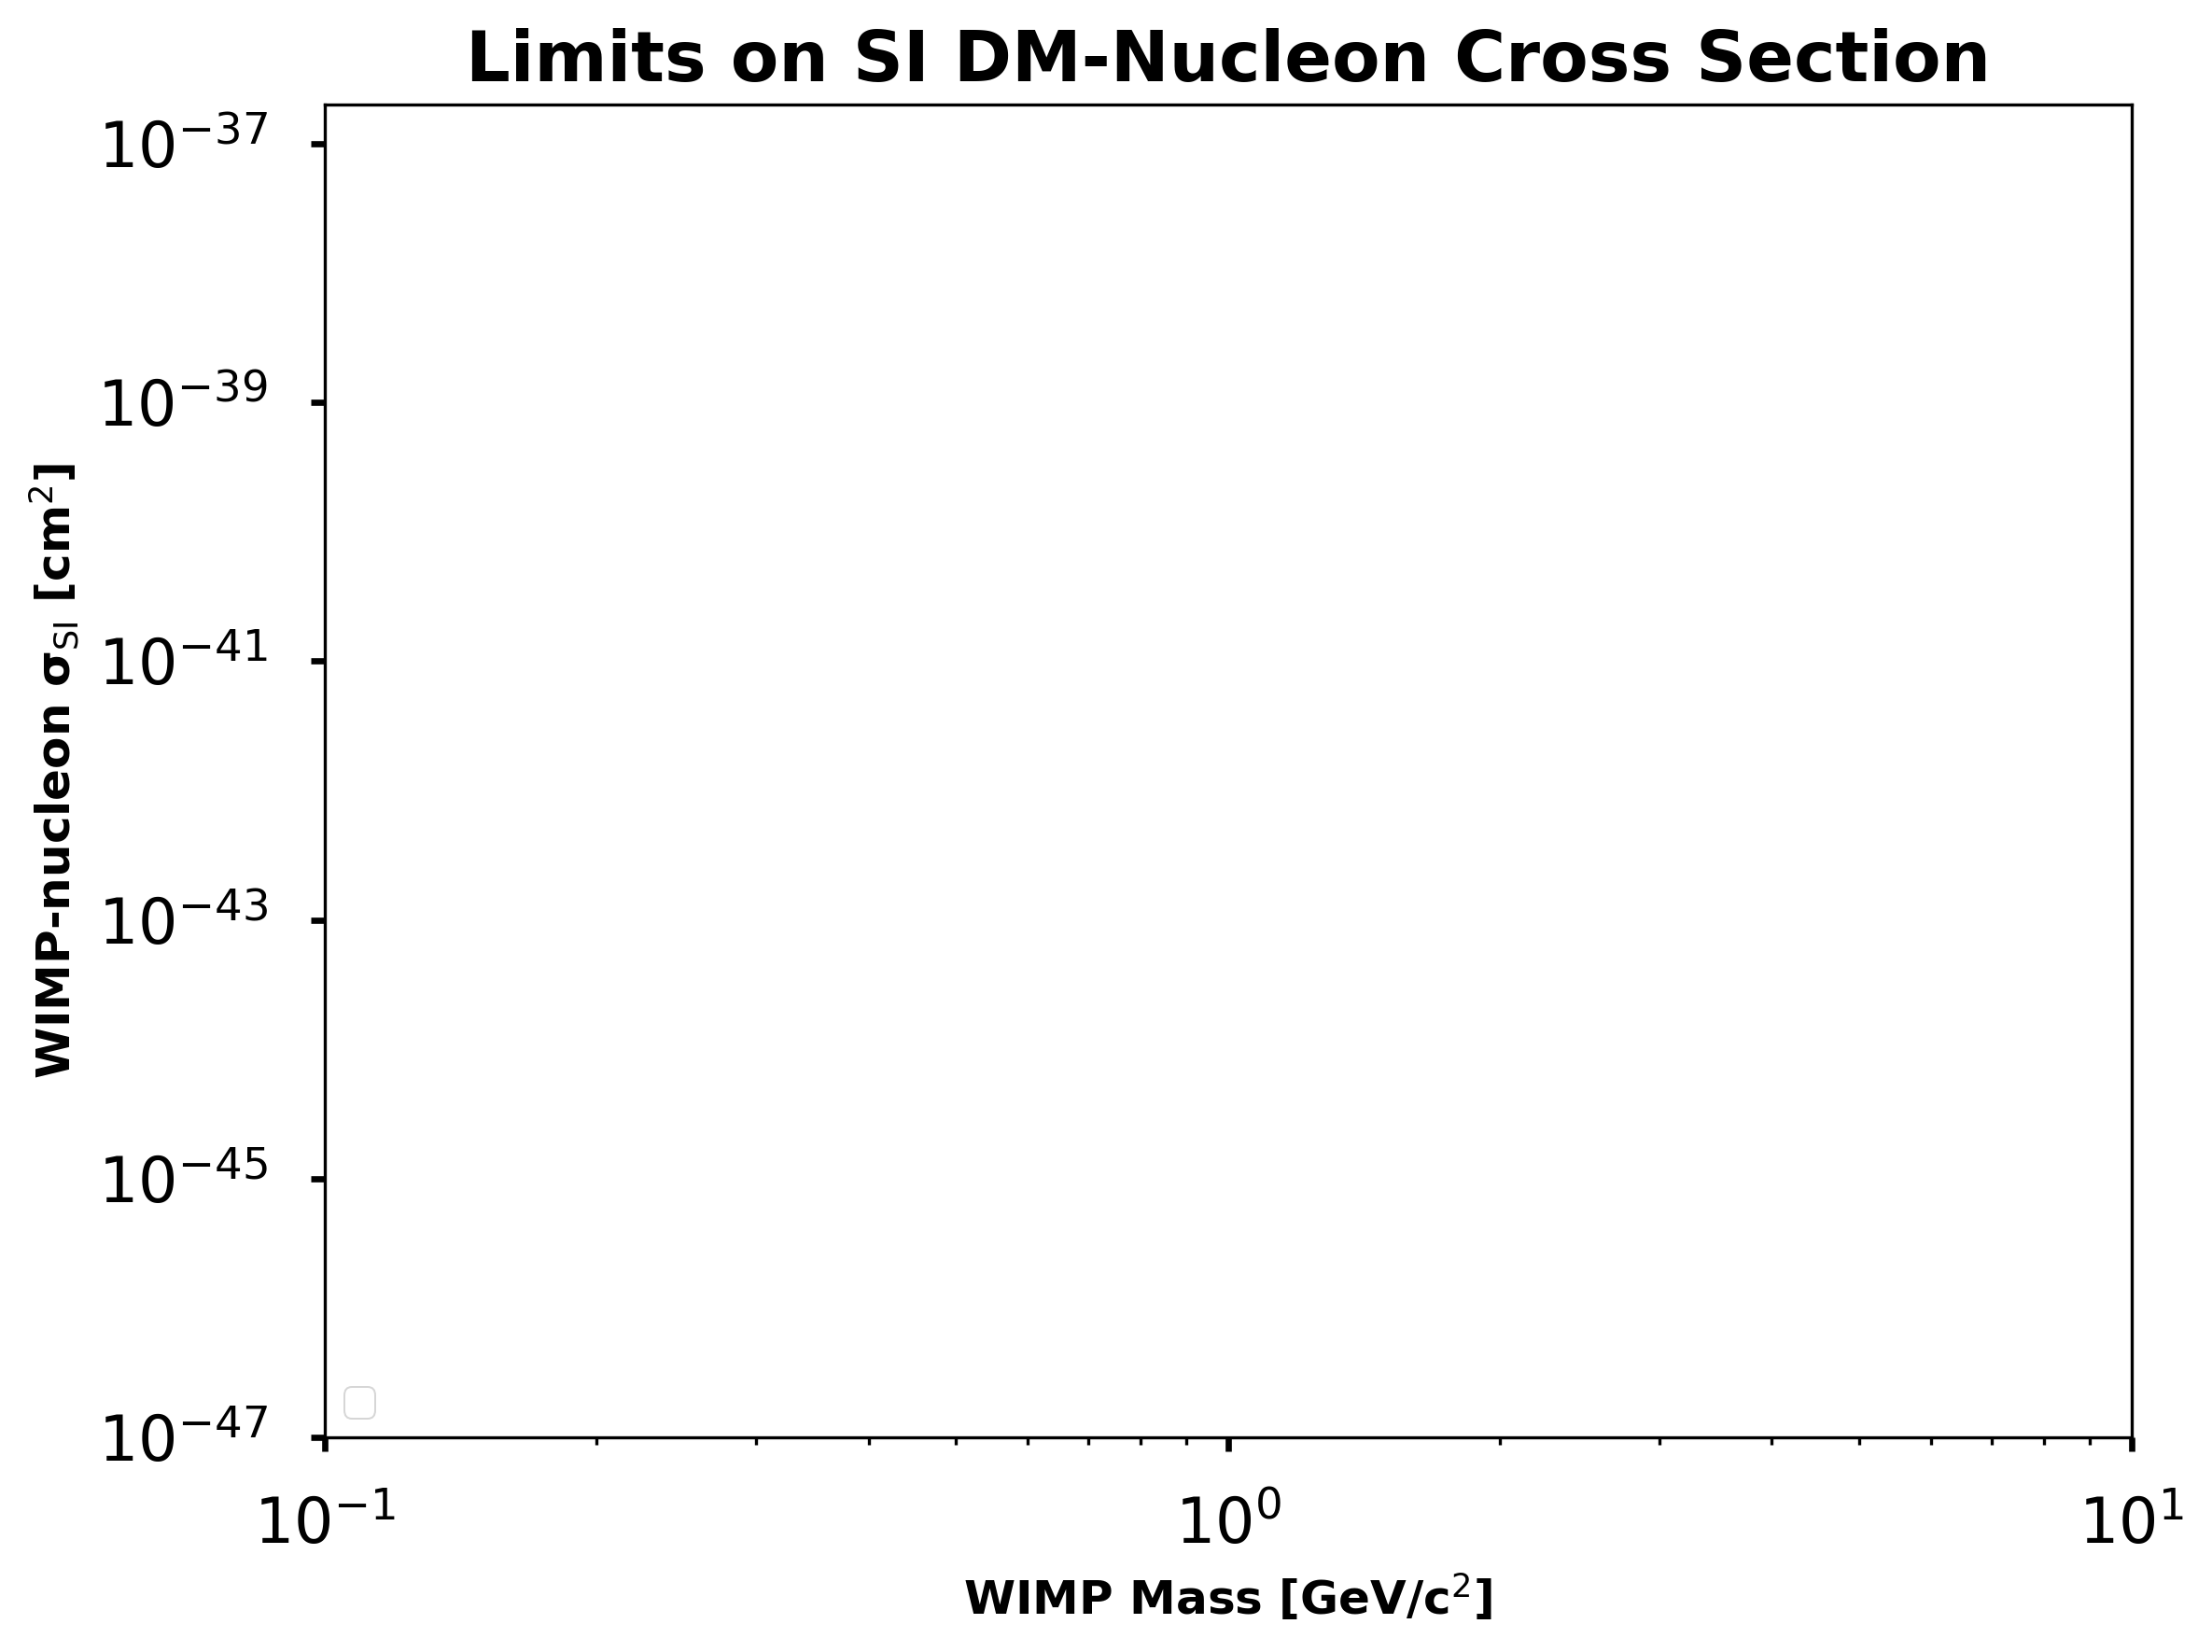

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_data_from_files(master_path, filenames):
    plt.style.use('seaborn-v0_8-poster')
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    projection_label = 'Projections'
    label_added_projection = False
    label_positions = []

    missing_files = []

    for filename in filenames:
        file_path = os.path.join(master_path, filename)
        if not os.path.exists(file_path):
            missing_files.append(filename)
            continue

        data = np.loadtxt(file_path)
        x, y = data[:, 0], data[:, 1]

        offset_values = {
            'XLZD_200ty(NR).txt': 1.,
            'XLZD_40t_140ty_migdal(This study).txt': 1.,
            'XLZD_60t_750ty_migdal(This study).txt': 1.,
            'XLZD_80t_950ty_migdal(This study).txt': 0.9,
        }

        if filename in offset_values:
            x_offset = x * offset_values[filename]  
            line, = ax.plot(x_offset, y, label=filename.replace('.txt', ''), lw=2.3, linestyle='--', alpha=1.)

            if filename in ['XLZD_200ty(NR).txt', 'XLZD_40t_140ty_migdal(This study).txt', 
                            'XLZD_60t_750ty_migdal(This study).txt', 'XLZD_80t_950ty_migdal(This study).txt']:
                if not label_added_projection:
                    ax.plot([], [], label=projection_label, linestyle='--', lw=2.3, alpha=1.)
                    label_added_projection = True

        elif filename == 'neutrino_fog.txt':
            ax.plot(x, y, color='blue', lw=2)
            ax.fill_between(x, y, color='lightblue', alpha=0.5)
            ax.text(1.5, 1e-46, "Neutrino Fog", color='black', fontsize=12, 
                    ha='left', va='bottom', fontweight='bold')

        elif filename == 'AllLimits-2024.txt':
            line, = ax.plot(x, y, color="black", label=filename.replace('.txt', ''), lw=2)
            ax.fill_between(x, y, ax.get_ylim()[1], color='lime', alpha=0.3)
            ax.text(2.3, 5e-41, 'Excluded Region', color='black', fontsize=12, 
                    ha='left', va='bottom', fontweight='bold')

        else:
            line, = ax.plot(x, y, label=filename.replace('.txt', ''), lw=1.5)

        if filename != 'neutrino_fog.txt':
            x_label = x[int(len(x) * 0.7)]
            y_label = y[int(len(x) * 0.7)] * 1.5

    if missing_files:
        print(f"Missing files: {', '.join(missing_files)}")

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim([0.1, 10])
    ax.set_ylim([1e-47, 2e-37])
    ax.set_xlabel(r'WIMP Mass [GeV/c$^2$]', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'WIMP-nucleon $\mathbf{\sigma_{\mathbf{\rm SI}}}$ [cm$^2$]', fontsize=12, fontweight='bold')
    ax.set_title("Limits on SI DM-Nucleon Cross Section", fontsize=18, fontweight='bold')

    ax.legend(loc='lower left', fontsize=10)
    plt.tight_layout()
    plt.show()

master_path = '/Users/amirr/Desktop/Flame/FlameFitSimple/analyses/Plotting'
filenames = [
    'XLZD_200ty(NR).txt', 'neutrino_fog.txt',
    "AllLimits-2024.txt", "XENON1T_Migdal_2020(S2-only)_1ty.txt",
    "XLZD_60t_750ty_migdal(This study).txt",
    "XLZD_40t_140ty_migdal(This study).txt",
    "XLZD_80t_950ty_migdal(This study).txt",
    'XENON1T_Migdal_2020(S1-S2)_1ty.txt',
    "LZ_SR1_Migdal_2023 _low_0.9ty.txt"
]

plot_data_from_files(master_path, filenames)
